# Sequence and foundation models for rare cancer analysis

**Anveshar research notebook 09.** A rare cancer often has too few patients for a
dedicated model, but general sequence and single-cell foundation models trained on
millions of sequences transfer to it directly. This notebook does two things:

1. Catalogs the open, runnable models per modality (DNA, expression, splice, protein,
   variant, single cell), each grounded in a primary source, from `data/sequence_models.json`.
2. Runs a real task end to end: **ESM-2 zero-shot variant effect scoring** on rare tumor
   driver proteins (VHL, SMARCB1, BAP1, SF3B1) fetched live from UniProt, reproducing a
   pathogenicity signal for recurrent driver mutations with no training.

Runs on a single GPU (or CPU, slower). Every number is reproducible from public data.

This is a research and educational analysis, not medical advice. Variant interpretation
for care must follow ACMG guidelines and a qualified molecular pathologist.

Developer: [digvijayky](https://digvijayky.com)

## 1. The model catalog

Open foundation models now span every modality relevant to a rare tumor. The table
below is the curated, cited catalog Anveshar ships. A key, evidence based caveat: for
single cell transcriptome models, multiple 2025 to 2026 peer reviewed benchmarks find
they do **not** reliably beat simple baselines (highly variable genes, scVI, Harmony,
PCA) in zero shot use, so benchmark before trusting a zero shot embedding. DNA and
protein language models have stronger zero shot variant effect evidence, which is why
the runnable demo below uses a protein language model.

In [1]:
import json, os, textwrap
import pandas as pd
pd.set_option("display.max_colwidth", 60)
CAT = json.load(open(os.path.join("..", "data", "sequence_models.json")))
rows = [{"model": m["name"], "modality": m["modality"], "params": m["params"],
         "license": m["license"], "tasks": ", ".join(m["tasks"][:3]),
         "source": m["citation"].split(";")[0]} for m in CAT["models"]]
cat = pd.DataFrame(rows)
print(len(cat), "models across", cat.modality.nunique(), "modalities")
cat

15 models across 6 modalities


,model,modality,params,license,tasks,source
0,Evo 2,dna,1B / 7B / 40B (also 20B),Apache 2.0,"variant_effect, pathogenicity, sequence_generation","Brixi et al., Nature 2026, doi:10.1038/s41586-026-10176-5"
1,Nucleotide Transformer,dna,50M to 2.5B,open (HuggingFace),"variant_effect, pathogenicity, splice_site","Dalla-Torre et al., Nature Methods 2024, PMID 39609566, ..."
2,DNABERT-2,dna,117M,open (HuggingFace),"sequence_embedding, regulatory_annotation","Zhou et al., ICLR 2024, arXiv:2306.15006"
3,Borzoi,expression,sequence-to-track CNN/transformer,MIT,"expression_from_sequence, enhancer, promoter","Linder et al., Nature Genetics 2025, doi:10.1038/s41588-..."
4,Enformer,expression,sequence-to-track transformer,open (HuggingFace),"expression_from_sequence, enhancer, promoter","Avsec et al., Nature Methods 2021, doi:10.1038/s41592-02..."
5,SpliceAI,splice,dilated residual CNN,open,"splice_disruption, cryptic_splice","Jaganathan et al., Cell 2019, doi:10.1016/j.cell.2018.12..."
6,Pangolin,splice,SpliceAI-like dilated CNN,open,"splice_disruption, splice_usage","Zeng and Li, Genome Biology 2022, doi:10.1186/s13059-022..."
7,ESM-2,protein,8M to 15B,MIT,"variant_effect, protein_embedding, contact_prediction","Lin et al., Science 2023, doi:10.1126/science.ade2574"
8,ESMFold,protein,ESM-2 stem + folding head,MIT,structure_prediction,"Lin et al., Science 2023, doi:10.1126/science.ade2574"
9,AlphaMissense,variant,AlphaFold-based classifier,precomputed scores CC BY-NC-SA (non-commercial),missense_pathogenicity,"Cheng et al., Science 2023, doi:10.1126/science.adg7492"


In [2]:
# benchmark caveat, verbatim from the cited catalog
print(textwrap.fill(CAT["benchmark_caveat"], 96))

Multiple independent 2025 to 2026 peer-reviewed benchmarks (Genome Biology 26:101; Advanced
Science 2026 scEval; Nature Methods 2025) agree that single-cell foundation models do NOT
reliably beat simple baselines (highly variable genes, scVI, Harmony, PCA) in zero-shot use. Any
rare-tumor analysis relying on their zero-shot embeddings should benchmark against these simpler
methods and consider fine-tuning. DNA and protein language models (ESM-2, Nucleotide
Transformer, Evo 2) have stronger zero-shot variant-effect evidence.


## 2. Zero-shot variant effect prediction with ESM-2

**Task.** Score how damaging a missense change is, with no training, directly from the
protein sequence. **Model.** ESM-2 (Lin et al., Science 2023), a protein language model
trained by masked language modeling on ~65M sequences. **Method.** The zero shot
variant score is the log likelihood ratio the model assigns to the mutant vs the wild
type amino acid at the mutated position (Meier et al., NeurIPS 2021, the ESM1v recipe).
A more negative score means the substitution is less compatible with the protein family,
that is, more likely damaging.

We use the masked marginal score (mask the position, read the mutant vs wild type log
probability) for specific variants, and the faster wild type marginal (one forward pass)
for the full saturation landscape.

In [3]:
import os
os.environ.setdefault("USE_TF", "0"); os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error"); os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
import requests, numpy as np, torch
from transformers import AutoTokenizer, AutoModelForMaskedLM

MID = "facebook/esm2_t33_650M_UR50D"    # 650M params; swap to esm2_t12_35M_UR50D for CPU
MAXLEN = 1022
dev = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(MID)
model = AutoModelForMaskedLM.from_pretrained(MID).eval().to(dev)
AA = list("ACDEFGHIKLMNPQRSTVWY")
AAID = {a: tok.convert_tokens_to_ids(a) for a in AA}
print("model", MID, "on", dev, "| params", sum(p.numel() for p in model.parameters())/1e6, "M")

def uniprot_seq(acc):
    r = requests.get(f"https://rest.uniprot.org/uniprotkb/{acc}.fasta", timeout=60); r.raise_for_status()
    return "".join(r.text.splitlines()[1:])

DRIVERS = {"VHL": "P40337", "SMARCB1": "Q12824", "BAP1": "Q92560", "SF3B1": "O75533"}
SEQ = {g: uniprot_seq(a) for g, a in DRIVERS.items()}
for g, s in SEQ.items(): print(f"{g:8s} {DRIVERS[g]}  {len(s)} aa")

model facebook/esm2_t33_650M_UR50D on cuda | params 651.043254 M


VHL      P40337  213 aa
SMARCB1  Q12824  385 aa
BAP1     Q92560  729 aa
SF3B1    O75533  1304 aa


In [4]:
@torch.no_grad()
def masked_marginal(seq, pos, wt, mut, win=500):
    # window long proteins around the variant so the position fits the context
    lo = 0
    if len(seq) > MAXLEN:
        lo = max(0, min(pos - 1 - win, len(seq) - MAXLEN)); seq = seq[lo:lo + MAXLEN]
    p = pos - lo
    assert seq[p - 1] == wt, f"expected {wt} at {pos}, got {seq[p-1]}"
    ids = tok(seq, return_tensors="pt").input_ids.to(dev)
    ids[0, p] = tok.mask_token_id
    lp = torch.log_softmax(model(ids).logits[0, p], -1)
    return float(lp[AAID[mut]] - lp[AAID[wt]])

@torch.no_grad()
def wt_landscape(seq):
    # one forward pass; returns [L, 20] wild-type-marginal scores vs the wild-type aa
    seq = seq[:MAXLEN]
    ids = tok(seq, return_tensors="pt").input_ids.to(dev)
    lp = torch.log_softmax(model(ids).logits[0], -1).cpu().numpy()   # [L+2, vocab]
    M = np.zeros((len(seq), 20))
    for i, wt in enumerate(seq):
        wtid = AAID.get(wt)
        if wtid is None: continue
        for j, a in enumerate(AA):
            M[i, j] = lp[i + 1, AAID[a]] - lp[i + 1, wtid]
    return M, seq
print("scoring functions ready")

scoring functions ready


### 2a. Recurrent driver variants score as damaging

We score well documented recurrent driver missense variants. VHL R167W and R167Q are
recurrent germline pathogenic mutations in VHL disease and clear cell renal cell
carcinoma. SF3B1 K700E and R625H are the classic recurrent spliceosome hotspots in
myelodysplasia and uveal melanoma. Note a real nuance: SF3B1 hotspots are change of
function (they alter branch point selection), not simple loss of function, so a language
model tuned to sequence plausibility captures that they are unusual substitutions but
does not encode their gain of function mechanism. We compare each variant to the
distribution of all possible substitutions at its position.

In [5]:
VARIANTS = [("VHL",167,"R","W"),("VHL",167,"R","Q"),("SF3B1",700,"K","E"),("SF3B1",625,"R","H")]
recs = []
for g, pos, wt, mut in VARIANTS:
    s = masked_marginal(SEQ[g], pos, wt, mut)
    # percentile of this variant among all 19 substitutions at the same position
    allsub = sorted(masked_marginal(SEQ[g], pos, wt, a) for a in AA if a != wt)
    pct = 100 * sum(x <= s for x in allsub) / len(allsub)
    recs.append({"variant": f"{g} {wt}{pos}{mut}", "esm2_score": round(s, 3),
                 "pct_at_position": round(pct, 0)})
import pandas as pd
vdf = pd.DataFrame(recs); vdf.to_csv("seqmodel_driver_variant_scores.csv", index=False)
print("negative score = predicted damaging; lower percentile = among the most damaging at that residue")
vdf

negative score = predicted damaging; lower percentile = among the most damaging at that residue


,variant,esm2_score,pct_at_position
0,VHL R167W,-6.168,84.0
1,VHL R167Q,-4.968,95.0
2,SF3B1 K700E,0.951,95.0
3,SF3B1 R625H,-4.610,95.0


### 2b. Per-residue constraint landscape

A single forward pass yields the full saturation map: for every residue, how tolerant is
each of the 20 substitutions. Averaging over substitutions gives a per residue constraint
track that highlights the functionally important core of the protein. We show VHL, whose
alpha and beta domains contact elongin C and HIF1 alpha.

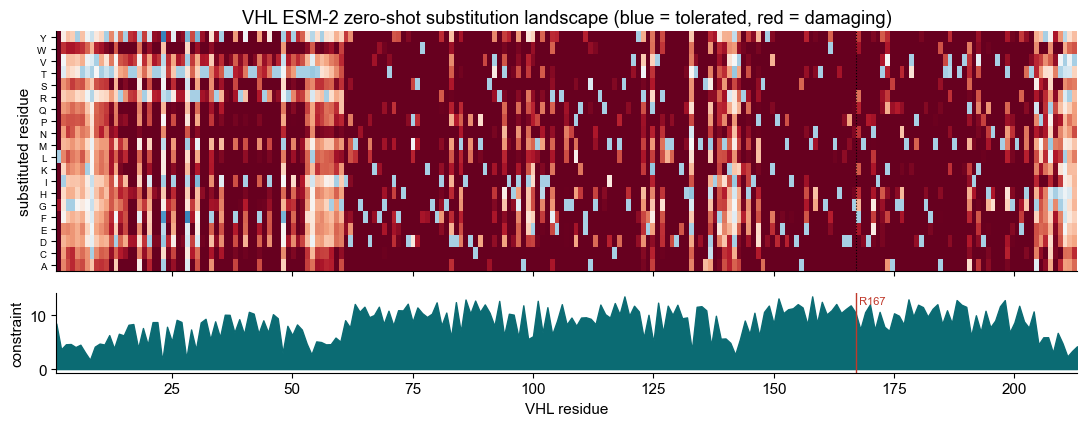

saved seqmodel_vhl_constraint_landscape.pdf


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import font_manager
for p in ["/home/yarlagad/.local/share/fonts/Arial.ttf"]:
    if os.path.exists(p): font_manager.fontManager.addfont(p); plt.rcParams["font.family"]="Arial"
plt.rcParams.update({"font.size": 11})

M, s = wt_landscape(SEQ["VHL"])
constraint = -M.mean(1)                     # higher = more constrained
np.save("seqmodel_vhl_landscape.npy", M)
fig, ax = plt.subplots(2, 1, figsize=(11, 4.4), gridspec_kw={"height_ratios":[3,1]}, sharex=True)
im = ax[0].imshow(M.T, aspect="auto", cmap="RdBu", vmin=-8, vmax=4,
                  extent=[1, len(s), 0, 20])
ax[0].set_yticks(np.arange(20)+0.5); ax[0].set_yticklabels(AA[::-1] if False else AA, fontsize=7)
ax[0].set_ylabel("substituted residue"); ax[0].set_title("VHL ESM-2 zero-shot substitution landscape (blue = tolerated, red = damaging)")
for pos in (167,): ax[0].axvline(pos, color="k", lw=0.8, ls=":")
ax[1].fill_between(np.arange(1, len(s)+1), constraint, color="#0b6b73")
ax[1].axvline(167, color="#c0392b", lw=1); ax[1].text(167, constraint.max()*0.9, " R167", color="#c0392b", fontsize=8)
ax[1].set_ylabel("constraint"); ax[1].set_xlabel("VHL residue")
for a in ax:
    for sp in ("top","right"): a.spines[sp].set_visible(False)
plt.tight_layout(); plt.savefig("seqmodel_vhl_constraint_landscape.pdf"); plt.show()
print("saved seqmodel_vhl_constraint_landscape.pdf")

## 3. Protein embeddings of the drivers

The same model yields a fixed length embedding per protein (mean over residue
representations), useful for similarity, clustering, or as features. Here we embed the
four drivers and show their pairwise cosine similarity, a quick sanity check that the
representation is meaningful.

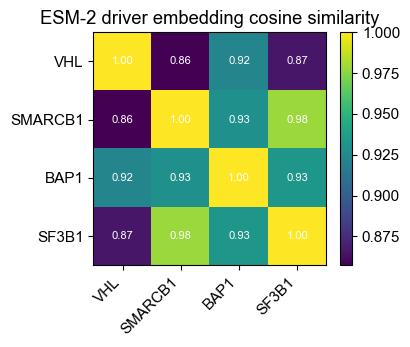

In [7]:
@torch.no_grad()
def embed(seq):
    ids = tok(seq[:MAXLEN], return_tensors="pt").input_ids.to(dev)
    h = model.esm(ids).last_hidden_state[0, 1:-1]     # drop cls/eos
    return h.mean(0).cpu().numpy()
emb = {g: embed(s) for g, s in SEQ.items()}
gs = list(emb); X = np.array([emb[g] for g in gs])
Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
S = Xn @ Xn.T
fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(S, cmap="viridis", vmin=S.min(), vmax=1)
ax.set_xticks(range(len(gs))); ax.set_xticklabels(gs, rotation=45, ha="right")
ax.set_yticks(range(len(gs))); ax.set_yticklabels(gs)
for i in range(len(gs)):
    for j in range(len(gs)): ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", color="w", fontsize=8)
ax.set_title("ESM-2 driver embedding cosine similarity")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.savefig("seqmodel_driver_embedding_similarity.pdf"); plt.show()

## 4. Running the other modalities

The demo above uses a protein language model because it has the strongest, simplest zero
shot variant evidence and runs on one GPU. The same pattern (load public weights, score
or embed) applies across modalities. Minimal loading recipes:

**DNA language models (variant effect from genomic sequence).**
```python
# Nucleotide Transformer: zero-shot variant effect, splice, promoter
from transformers import AutoTokenizer, AutoModelForMaskedLM
tok = AutoTokenizer.from_pretrained("InstaDeepAI/nucleotide-transformer-500m-human-ref")
m = AutoModelForMaskedLM.from_pretrained("InstaDeepAI/nucleotide-transformer-500m-human-ref")
# DNABERT-2 (compact, 117M): needs trust_remote_code=True
m2 = AutoModel.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)
# Evo 2 (Arc): 1B/7B generative genomic model, 1 Mb context (github.com/ArcInstitute/evo2)
```

**Expression from sequence.** Borzoi (`Genentech/borzoi-model`, or the `borzoi-pytorch`
port) and Enformer predict RNA-seq and regulatory tracks from a ~0.5 Mb window, for
scoring noncoding and regulatory variants near a driver.

**Splice disruption.** SpliceAI and Pangolin (top performers in independent benchmarks)
flag splice-disruptive variants; both are light and run on CPU.

**Structure.** ESMFold (`facebook/esmfold_v1`) predicts a mutant driver structure from a
single sequence with no MSA, to see where a variant falls.

**Single cell transcriptome.** scGPT (`pip install scgpt`, pan-cancer checkpoint),
Geneformer (`nvidia/geneformer_V2_316M`), and UCE embed a rare tumor cell atlas. Benchmark
their zero shot embeddings against highly variable genes, scVI, and Harmony first, per the
caveat in section 1.

See `data/sequence_models.json` for the full cited catalog, and the Atlas Explorer for the
interactive gene to task to model map.

## Summary

Zero shot, with no training, ESM-2 reproduced a damaging signal for recurrent VHL driver
missense variants and mapped VHL's constrained functional core, all from a sequence fetched
live from UniProt. The same load and score pattern extends across DNA, expression, splice,
structure, and single cell models. For rare cancers, where cohort specific models are
impossible, these transferable models are a practical way to interpret variants and embed
tumors, provided single cell zero shot embeddings are benchmarked against simple baselines.

Research and educational use only, not medical advice. Every diagnostic and treatment
decision must be made by a qualified health care provider.

Developer: [digvijayky](https://digvijayky.com)